# Lab 2 · A 1D CNN on Real Clinical Spectra
**MSACL · DS301 Deep Learning · Segment 2 · Lab 2**

Last lab you built a network that reads a *table* of metabolite numbers. This lab, you'll
build one that reads a **spectrum** — the same 1D-CNN idea from Lecture 5, trained on real
**MALDI-TOF mass spectra** to call antimicrobial resistance straight from the instrument's
raw signal.

This is a ~45-minute session (+ 10 min discussion). **You fill in four short pieces**, all
about the new parts: the training loop reused on spectra, the CNN itself, and the batch size.
Everything else runs as-is.


## About the data: DRIAMS MALDI-TOF spectra

**DRIAMS** is a public database of routine clinical **MALDI-TOF mass spectra** paired with
antimicrobial-resistance lab results — the same kind of spectrum a clinical microbiology lab
already collects to identify a pathogen, here reused to predict whether it will respond to an
antibiotic *before* the days-long culture-based test comes back.

Today's task: **_Staphylococcus aureus_ + oxacillin** — the classic **MRSA** call. Each sample
is one spectrum, already reduced by the instrument's own processing pipeline to a fixed
**6,000-number vector** (intensity at each of 6,000 mass positions), with a label:

- **0 = susceptible** (oxacillin will likely work)
- **1 = resistant** (MRSA — a different antibiotic is needed)

> **Note:** this lab runs on a smaller *development slice* of DRIAMS (one hospital site,
> 738 spectra) — the full course dataset is larger and better balanced. The code here works
> identically either way; only the data file changes.


In [1]:
# Read and run — no need to edit.
import os
import urllib.request
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)
print("Libraries ready.")


Libraries ready.


/Users/lixingsong/Teaching/MSACL_DL_Course/student_pack/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 · Load the spectra *(runs for you)*

In [2]:
# Read and run — no need to edit.
# The data lives in this repo for local development; in Colab it downloads instead.
LOCAL_PATH = Path("../../data/slices/driams_c_saureus_oxacillin.npz")
RAW_URL = "https://raw.githubusercontent.com/<ORG>/<REPO>/main/data/slices/driams_c_saureus_oxacillin.npz"

if LOCAL_PATH.exists():
    npz_path = LOCAL_PATH
else:
    npz_path = Path("driams_c_saureus_oxacillin.npz")
    if not npz_path.exists():
        urllib.request.urlretrieve(RAW_URL, npz_path)

data = np.load(npz_path)
X = data["X"].astype("float32")   # shape (738, 6000): raw binned intensities
y = data["y"].astype("float32")   # 0 = susceptible, 1 = resistant

print("Spectra:", X.shape, "| resistant:", int(y.sum()), "/", len(y))


Spectra: (738, 6000) | resistant: 41 / 738


Here's what two real spectra look like — one susceptible, one resistant. Visually they're
very similar; the network's job is to find the subtle pattern a human eye can't easily spot.


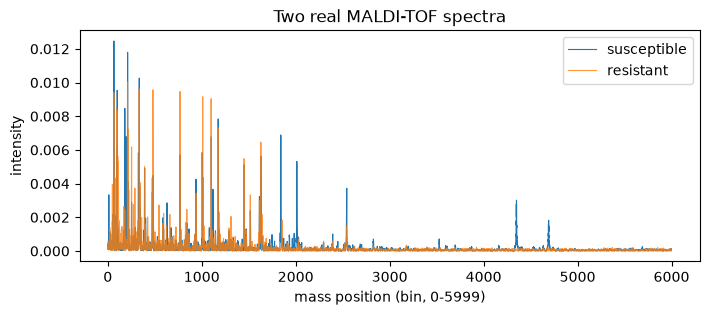

In [3]:
# Read and run — no need to edit.
sus_row = np.where(y == 0)[0][0]
res_row = np.where(y == 1)[0][0]

plt.figure(figsize=(8, 3))
plt.plot(X[sus_row], linewidth=0.8, label="susceptible")
plt.plot(X[res_row], linewidth=0.8, label="resistant", alpha=0.8)
plt.xlabel("mass position (bin, 0-5999)"); plt.ylabel("intensity")
plt.title("Two real MALDI-TOF spectra")
plt.legend()
plt.show()


## Step 2 · Split, balance-check, and normalize — by hand *(runs for you)*

Only **41 of 738** spectra are resistant (~5.6%) — a realistic clinical imbalance (MRSA is
the minority case). A plain shuffle-split could easily starve the test set of resistant
examples entirely, so we split **within each class separately**, then combine — this is
called a **stratified split**, and it guarantees both the train and test sets contain
resistant examples.

We also **normalize each spectrum by its own peak intensity** — instrument runs vary in
overall signal strength, so this puts every spectrum on the same 0–1 scale before training.


In [4]:
# Read and run — no need to edit.
# --- stratified 80/20 split: split resistant and susceptible indices separately ---
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

n_pos_train = int(0.8 * len(pos_idx))
n_neg_train = int(0.8 * len(neg_idx))

train_idx = np.concatenate([pos_idx[:n_pos_train], neg_idx[:n_neg_train]])
test_idx = np.concatenate([pos_idx[n_pos_train:], neg_idx[n_neg_train:]])
np.random.shuffle(train_idx)   # mix classes together within the split
np.random.shuffle(test_idx)

# --- normalize: divide each spectrum by its own maximum intensity ---
X_norm = X / X.max(axis=1, keepdims=True)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"train: {len(train_idx)} spectra ({int(y_train.sum())} resistant)")
print(f"test:  {len(test_idx)} spectra ({int(y_test.sum())} resistant)")

# tensors: add a "channel" dimension of size 1 for Conv1d -> shape (N, 1, 6000)
X_train_t = torch.tensor(X_train).unsqueeze(1)
X_test_t = torch.tensor(X_test).unsqueeze(1)
y_train_t = torch.tensor(y_train).unsqueeze(1)
y_test_t = torch.tensor(y_test).unsqueeze(1)

# resistant cases are rare -> up-weight them for the plain loss so the model can't just
# ignore them and still score well (you'll meet this idea again in Lecture 10)
n_pos, n_neg = y_train.sum(), len(y_train) - y_train.sum()
pos_weight = torch.tensor([n_neg / n_pos])
print(f"class imbalance: resistant examples are {pos_weight.item():.1f}x rarer than susceptible")


train: 589 spectra (32 resistant)
test:  149 spectra (9 resistant)
class imbalance: resistant examples are 17.4x rarer than susceptible


## Step 3 · The training loop — YOUR TURN ✏️

This is the **exact same recipe** from Lecture 2 / Lab 1 — forward, loss, zero, backward,
step — reused here for spectra, in **mini-batches** (train on a handful of spectra at a
time, many times per epoch, rather than all 590 at once). We wrap it in a function so we
can reuse it for the different comparisons below, with a **live progress bar** showing the
loss as it trains.

**Fill in the five lines** inside the batch loop, in order (same names as Lab 1):


In [5]:
def train_model(model, X, y, epochs, batch_size, lr, loss_fn):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X.shape[0]
    loss_history = []

    pbar = tqdm(range(epochs), desc="training")
    for epoch in pbar:
        order = torch.randperm(n)                       # shuffle sample order each epoch
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            batch_idx = order[start:start + batch_size]
            X_batch, y_batch = X[batch_idx], y[batch_idx]

            ### BEGIN SOLUTION
            pred = model(X_batch)                        # 1. forward  — make a guess
            loss = loss_fn(pred, y_batch)                # 2. loss     — how wrong?
            optimizer.zero_grad()                        # 3. zero     — clear old gradients
            loss.backward()                              # 4. backward — backprop the blame
            optimizer.step()                              # 5. step     — nudge every weight
            ### END SOLUTION

            epoch_loss += loss.item() * len(batch_idx)
        avg_loss = epoch_loss / n
        loss_history.append(avg_loss)
        pbar.set_postfix(loss=f"{avg_loss:.3f}")          # live loss monitor on the progress bar
    return loss_history

# --- self-check: do not edit ---
_probe_model = nn.Linear(4, 1)
_probe_X = torch.randn(20, 4)
_probe_y = torch.randint(0, 2, (20, 1)).float()
_probe_history = train_model(_probe_model, _probe_X, _probe_y, epochs=2, batch_size=5,
                              lr=0.01, loss_fn=nn.BCEWithLogitsLoss())
assert len(_probe_history) == 2, f"expected 2 loss values (one per epoch), got {len(_probe_history)}"
assert all(isinstance(v, float) for v in _probe_history), "loss_history should hold plain floats"
print("Loop checks out — 2 epochs ran, loss history:", [round(v, 3) for v in _probe_history])


training: 100%|██████████| 2/2 [00:00<00:00, 52.08it/s, loss=0.679]

Loop checks out — 2 epochs ran, loss history: [0.693, 0.679]


In [6]:
# Read and run — no need to edit.
def evaluate_model(model, X, y):
    with torch.no_grad():
        probs = torch.sigmoid(model(X))
    predicted = (probs > 0.5).float()
    accuracy = (predicted == y).float().mean().item()
    # resistant recall: of the truly-resistant cases, how many did we catch?
    is_resistant = (y == 1)
    if is_resistant.sum() > 0:
        recall = (predicted[is_resistant] == 1).float().mean().item()
    else:
        recall = float("nan")
    return accuracy, recall

print("Evaluation helper ready.")


Evaluation helper ready.


## Step 4 · Build the 1D CNN — YOUR TURN ✏️

A CNN doesn't need every position wired to every neuron — it slides a small **filter** along
the m/z axis, the same "peak detector everywhere" idea from Lecture 5. Fill in **two** conv
blocks:

**Blank 1 — the first `Conv1d`.** Use exactly the arguments from the Lecture 5 code slide:
one input channel (a raw spectrum), 8 filters, a filter that's 15 bins wide, and padding so
the output stays the same length.

**Blank 2 — a second conv block.** Mirror block 1's pattern (`Conv1d` → `ReLU` → `MaxPool1d`),
but now reading the **8** channels block 1 produced and turning them into **16**.


In [7]:
class SpectrumCNN(nn.Module):
    def __init__(self):
        super().__init__()

        ### BEGIN SOLUTION
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=15, padding=7)
        ### END SOLUTION
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(4)     # 6000 -> 1500

        ### BEGIN SOLUTION
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=15, padding=7)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(4)     # 1500 -> 375
        ### END SOLUTION

        self.flatten = nn.Flatten()               # (N, 16, 375) -> (N, 6000)
        self.fc1 = nn.Linear(16 * 375, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        return self.fc2(x)

# --- self-checks: do not edit ---
_probe = SpectrumCNN()
_out1 = _probe.pool1(_probe.relu1(_probe.conv1(torch.zeros(2, 1, 6000))))
assert _out1.shape == (2, 8, 1500), f"expected (2, 8, 1500) after block 1, got {tuple(_out1.shape)}"
_out2 = _probe.pool2(_probe.relu2(_probe.conv2(_out1)))
assert _out2.shape == (2, 16, 375), f"expected (2, 16, 375) after block 2, got {tuple(_out2.shape)}"
print("Shapes check out — block 1:", tuple(_out1.shape), "→ block 2:", tuple(_out2.shape))


Shapes check out — block 1: (2, 8, 1500) → block 2: (2, 16, 375)


## Step 5 · Choose a batch size — YOUR TURN ✏️

Bigger batches give a smoother, more confident gradient but fewer updates per epoch (and can
generalize *worse*, from Lecture 4); tiny batches are noisy but update often. Pick a
reasonable **middle-ground** batch size for 590 training spectra.


In [8]:
### BEGIN SOLUTION
CNN_BATCH_SIZE = 32
### END SOLUTION

# --- self-check: do not edit ---
assert 4 <= CNN_BATCH_SIZE <= 128, "pick a batch size between 4 and 128 - see Lecture 4's Goldilocks range"
print("Using batch size:", CNN_BATCH_SIZE)


Using batch size: 32


## Step 6 · Train the CNN *(runs for you)*

Watch the progress bar's loss shrink as it trains.


training: 100%|██████████| 10/10 [01:45<00:00, 10.54s/it, loss=1.233]


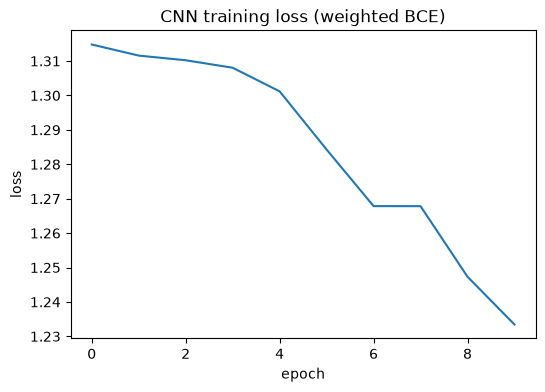

CNN (weighted BCE)  ->  test accuracy: 0.68   resistant recall: 0.56


In [9]:
# Read and run — no need to edit.
vanilla_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

cnn = SpectrumCNN()
cnn_losses = train_model(cnn, X_train_t, y_train_t, epochs=10, batch_size=CNN_BATCH_SIZE,
                          lr=0.001, loss_fn=vanilla_loss_fn)
cnn_acc, cnn_recall = evaluate_model(cnn, X_test_t, y_test_t)

plt.figure(figsize=(6, 4))
plt.plot(cnn_losses)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("CNN training loss (weighted BCE)")
plt.show()

print(f"CNN (weighted BCE)  ->  test accuracy: {cnn_acc:.2f}   resistant recall: {cnn_recall:.2f}")


**Read the recall number, not just accuracy.** With only ~92% of spectra susceptible, a lazy
model that always guesses "susceptible" already scores ~92% accuracy while catching **zero**
resistant cases — exactly the trap Lecture 10 warns about. Recall tells you whether the model
is actually doing the clinically important part of the job. Don't expect a perfect score —
on a slice this small, catching a *meaningful fraction* (not zero, not all) of the resistant
cases is the realistic, honest outcome.


## Step 7 · A better loss for rare cases: focal loss *(runs for you)*

`pos_weight` up-weights every resistant example equally. **Focal loss** (Lecture 4) goes a
step further: it down-weights examples the model *already gets right confidently*, so
training effort concentrates on the **hard, easy-to-miss** cases — exactly the rare
resistant spectra sitting close to the decision boundary. It also carries an `alpha` term
that (like `pos_weight`) tilts the balance toward the rare resistant class — without it the
model just learns to call everything susceptible.


training: 100%|██████████| 10/10 [01:44<00:00, 10.50s/it, loss=0.057]


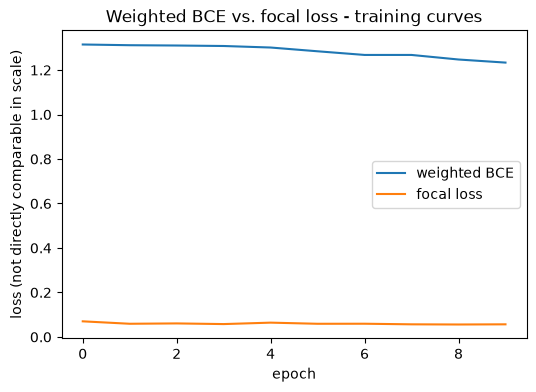

CNN (weighted BCE)  ->  test accuracy: 0.68     resistant recall: 0.56
CNN (focal loss)    ->  test accuracy: 0.94     resistant recall: 0.00


In [10]:
# Read and run — no need to edit.
def focal_loss(logits, targets, alpha=0.946, gamma=2.0):
    p = torch.sigmoid(logits)
    ce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    focal_w = (targets - p).abs().pow(gamma)                       # shrinks toward 0 for easy/confident cases
    alpha_t = targets * alpha + (1 - targets) * (1 - alpha)         # class balance: up-weight the rare resistant cases
    return (alpha_t * focal_w * ce).mean()

cnn_focal = SpectrumCNN()
focal_losses = train_model(cnn_focal, X_train_t, y_train_t, epochs=10, batch_size=CNN_BATCH_SIZE,
                            lr=0.001, loss_fn=focal_loss)
focal_acc, focal_recall = evaluate_model(cnn_focal, X_test_t, y_test_t)

plt.figure(figsize=(6, 4))
plt.plot(cnn_losses, label="weighted BCE")
plt.plot(focal_losses, label="focal loss")
plt.xlabel("epoch"); plt.ylabel("loss (not directly comparable in scale)")
plt.title("Weighted BCE vs. focal loss - training curves")
plt.legend()
plt.show()

print(f"CNN (weighted BCE)  ->  test accuracy: {cnn_acc:.2f}     resistant recall: {cnn_recall:.2f}")
print(f"CNN (focal loss)    ->  test accuracy: {focal_acc:.2f}     resistant recall: {focal_recall:.2f}")


The two loss *values* aren't on the same scale (focal loss is deliberately shrunk for easy
examples), so don't compare the curves' heights — compare the **recall** each model reaches.
Focal loss doesn't always win on a dataset this small and noisy, but it's the technique
you'd reach for first on a larger, similarly-imbalanced clinical dataset.


## What just happened

You adapted the Lab 1 recipe to a real clinical signal:
- the **same five-line training loop**, now wrapped for **mini-batches** with a live progress bar,
- a **1D CNN** that slides filters along the m/z axis instead of flattening everything,
- an honest look at **imbalanced classification** — accuracy alone would have hidden a model
  that never catches a single resistant case,
- two ways to fight that imbalance in the loss itself: **class weighting** and **focal loss**.

With only 738 spectra from one site, don't expect huge numbers — the point is the *shape* of
the recipe, which is identical on the full production dataset.


## Optional stretch *(only if you're ahead)*

A tiny **grid search**: try a few combinations of learning rate and batch size, and see which
does best on the test set. This is the "grid vs. random search" idea from Lecture 4, in code.
(Curious? Try swapping `loss_fn=vanilla_loss_fn` for `loss_fn=focal_loss` in the grid too.)


In [11]:
# Optional - read and run, or tweak the grids yourself.
results = []
for lr in [0.0005, 0.005]:
    for bs in [16, 64]:
        m = SpectrumCNN()
        train_model(m, X_train_t, y_train_t, epochs=10, batch_size=bs, lr=lr, loss_fn=vanilla_loss_fn)
        acc, recall = evaluate_model(m, X_test_t, y_test_t)
        results.append((lr, bs, acc, recall))

print(f"{'lr':>8} {'batch':>7} {'accuracy':>10} {'recall':>8}")
for lr, bs, acc, recall in sorted(results, key=lambda r: -r[3]):
    print(f"{lr:>8} {bs:>7} {acc:>10.2f} {recall:>8.2f}")


training: 100%|██████████| 10/10 [01:08<00:00,  6.83s/it, loss=1.313]


      lr   batch   accuracy   recall
   0.005      64       0.06     1.00
  0.0005      64       0.72     0.67
  0.0005      16       0.94     0.00
   0.005      16       0.94     0.00


## Discussion (10 min)

**Where in your workflow is there a 1D signal a CNN could read? Who labels it today, and how
well?** Think of a chromatogram, a QC trace, or another spectrum you see routinely — and how
confident a human currently is when reading it.
